# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4304s 25us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

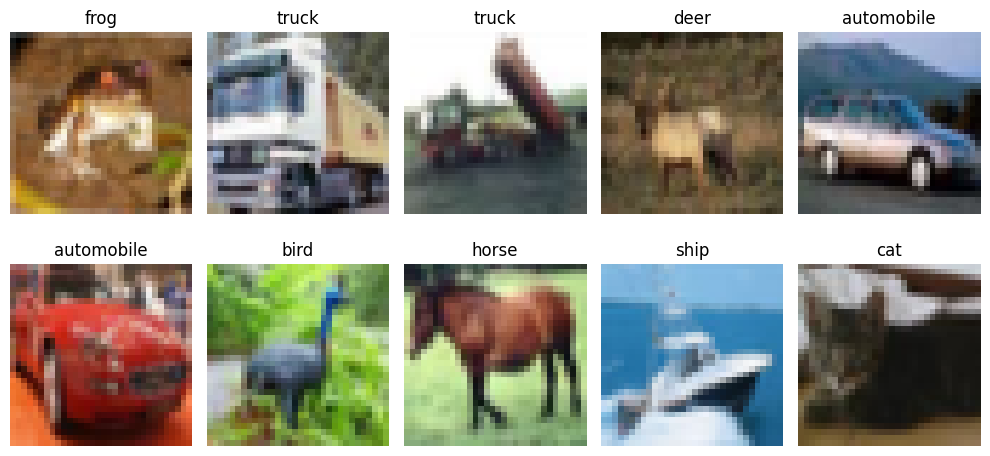

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0-255 to 0-1** so training becomes stable.

In [6]:
# Cast to float32 and scale to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten for ANN: (32,32,3) -> 3072
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized shape:", x_train_norm.shape)
print("Flattened shape: ", x_train_flat.shape)

Normalized shape: (50000, 32, 32, 3)
Flattened shape:  (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
# Build ANN using flattened input (3072 features)
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2642 - loss: 2.0040 - val_accuracy: 0.3154 - val_loss: 1.8637
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3151 - loss: 1.8738 - val_accuracy: 0.3596 - val_loss: 1.7676
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3348 - loss: 1.8284 - val_accuracy: 0.3758 - val_loss: 1.7611
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3468 - loss: 1.7903 - val_accuracy: 0.4014 - val_loss: 1.7253
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3537 - loss: 1.7644 - val_accuracy: 0.3946 - val_loss: 1.7122
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3594 - loss: 1.7494 - val_accuracy: 0.4180 - val_loss: 1.6759
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3689 - loss: 1.7373 - val_accuracy: 0.4078 - val_loss: 1.7035
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3726 - loss: 1.7223 - val_accuracy: 0.

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc*100:.2f}%")

ANN Test Accuracy: 43.55%


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
# CNN with 3 Conv blocks: filters 32 -> 64 -> 128
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Baseline')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4379 - loss: 1.5725 - val_accuracy: 0.5260 - val_loss: 1.3150
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5875 - loss: 1.1687 - val_accuracy: 0.6216 - val_loss: 1.0787
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6596 - loss: 0.9707 - val_accuracy: 0.6318 - val_loss: 1.0820
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7052 - loss: 0.8354 - val_accuracy: 0.6604 - val_loss: 0.9768
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7453 - loss: 0.7228 - val_accuracy: 0.6926 - val_loss: 0.9041
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7817 - loss: 0.6252 - val_accuracy: 0.6440 - val_loss: 1.1029
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8052 - loss: 0.5480 - val_accuracy: 0.7152 - val_loss: 0.8572
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8334 - loss: 0.4750 - 

In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc*100:.2f}%")

CNN Test Accuracy: 71.48%


## 📈 Compare Learning Curves

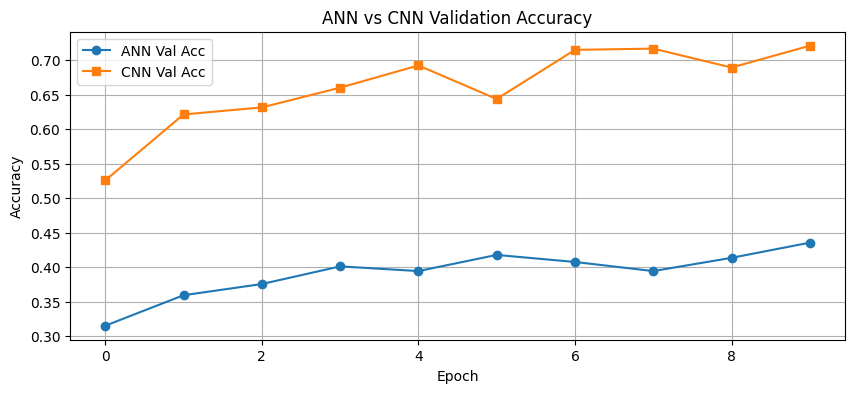

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [14]:
# Augmentation pipeline - active only during training
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Augmentation')

# Augmented CNN - same 32->64->128 filter progression with augmentation prepended
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='Aug_CNN')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "Aug_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32->64->128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

---
## Task 1 - Deeper ANN (3 hidden layers: 512 -> 256 -> 128)
The baseline ANN only had 2 hidden layers. Here we add a **third layer** (512 -> 256 -> 128)
to give it more depth without making it too wide.

## Task 2 - CNN Filters 32 -> 64 -> 128
Already implemented above in both `cnn_model` and `aug_cnn_model`. Each block doubles
the filters so the network can detect more complex patterns at each stage.

## Task 3 - Train for 20 Epochs
The augmented CNN below trains for up to 20 epochs instead of 10.

## Task 4 - EarlyStopping
We add `EarlyStopping` with `patience=3` so training stops automatically
when `val_loss` stops improving — preventing wasted compute and overfitting.

## Task 5 - Data Augmentation Training
The `aug_cnn_model` above has augmentation baked in. We now actually **train** it
(unlike the original notebook where it was commented out).

In [15]:
# Task 1: Deeper ANN - 3 hidden layers (512 -> 256 -> 128)
# Original only had 2 hidden layers (512 -> 256). Adding a third improves depth.

deeper_ann = models.Sequential([
    # Input: flattened 3072-dim vector
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # NEW third hidden layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
], name='Deeper_ANN_3Layers')

deeper_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_ann.summary()

Model: "Deeper_ANN_3Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the deeper ANN
deeper_ann_history = deeper_ann.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

deeper_ann_loss, deeper_ann_acc = deeper_ann.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nDeeper ANN (3 layers) Test Accuracy: {deeper_ann_acc*100:.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2165 - loss: 2.0789 - val_accuracy: 0.3126 - val_loss: 1.8900
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2787 - loss: 1.9434 - val_accuracy: 0.3176 - val_loss: 1.8985
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2941 - loss: 1.9000 - val_accuracy: 0.3294 - val_loss: 1.8778
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3077 - loss: 1.8785 - val_accuracy: 0.3344 - val_loss: 1.8450
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3182 - loss: 1.8596 - val_accuracy: 0.3474 - val_loss: 1.8148
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3255 - loss: 1.8462 - val_accuracy: 0.3636 - val_loss: 1.7980
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3298 - loss: 1.8336 - val_accuracy: 0.3598 - val_loss: 1.8016
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3374 - loss: 1.8181 - val_accuracy: 0.

In [17]:
# Task 4: EarlyStopping - stops if val_loss does not improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Task 3 + Task 5: Train augmented CNN for up to 20 epochs with EarlyStopping
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,              # Task 3: 20 epochs max
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop], # Task 4: auto-stop when val_loss plateaus
    verbose=1               # Task 5: aug_cnn_model has augmentation built-in
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3654 - loss: 1.7573 - val_accuracy: 0.3808 - val_loss: 1.9584
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4706 - loss: 1.4616 - val_accuracy: 0.5518 - val_loss: 1.3165
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5292 - loss: 1.3257 - val_accuracy: 0.5372 - val_loss: 1.3871
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5620 - loss: 1.2373 - val_accuracy: 0.6298 - val_loss: 1.1373
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5933 - loss: 1.1664 - val_accuracy: 0.6756 - val_loss: 0.9430
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6136 - loss: 1.1105 - val_accuracy: 0.6300 - val_loss: 1.1310
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6307 - loss: 1.0701 - val_accuracy: 0.6324 - val_loss: 1.0354
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6461 - loss: 1.0286 - 

In [18]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN + Data Augmentation Test Accuracy: {aug_test_acc*100:.2f}%")

CNN + Data Augmentation Test Accuracy: 67.75%


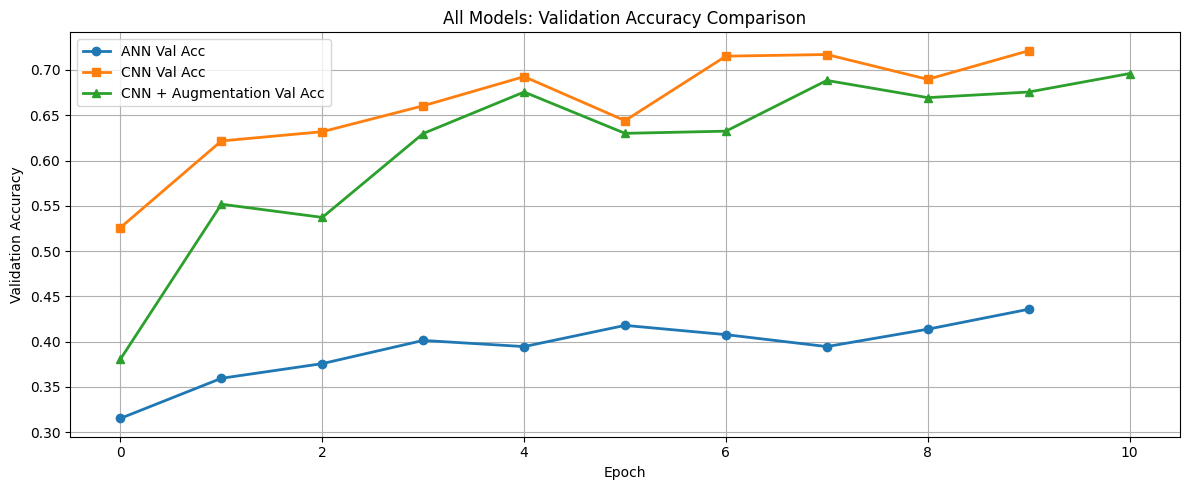

In [19]:
# Plot validation accuracy for all 3 models side by side
plt.figure(figsize=(12, 5))
plt.plot(ann_history.history['val_accuracy'],
         label='ANN Val Acc', marker='o', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'],
         label='CNN Val Acc', marker='s', linewidth=2)
plt.plot(aug_history.history['val_accuracy'],
         label='CNN + Augmentation Val Acc', marker='^', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('All Models: Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📊 Final Comparison Table

In [20]:
comparison = pd.DataFrame({
    'Model':         ['ANN', 'CNN', 'CNN + Data Augmentation'],
    'Test Accuracy': [
        f"{ann_test_acc*100:.2f}%",
        f"{cnn_test_acc*100:.2f}%",
        f"{aug_test_acc*100:.2f}%"
    ]
})

print('\n=== Final Model Comparison ===')
comparison


=== Final Model Comparison ===


,Model,Test Accuracy
0,ANN,43.55%
1,CNN,71.48%
2,CNN + Data Augmentation,67.75%


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**